# Redes Generativas Adversariales (GANs) en TensorFlow / Keras

Este notebook cubre las GANs desde sus fundamentos matematicos hasta implementaciones practicas en Keras. Se desarrollan cuatro variantes con complejidad creciente: GAN vanilla, DCGAN, GAN condicional (cGAN) y WGAN-GP. El dataset es MNIST.

Como el entrenamiento de las GANs requiere alternar dos optimizadores y combinar perdidas, se usa `tf.GradientTape` con bucles de entrenamiento personalizados en lugar de `model.fit()` estandar.

---

## Contenidos

1. Fundamentos matematicos
2. Preparacion del entorno y datos
3. GAN vanilla (MLP)
4. DCGAN (convolucional)
5. GAN Condicional (cGAN)
6. WGAN con gradiente penalizado (WGAN-GP)
7. Problemas comunes y diagnostico
8. Comparativa de variantes

---

## 1. Fundamentos matematicos

### El juego adversarial

Una GAN (Goodfellow et al., 2014) formula la generacion como un **juego de suma cero** entre dos redes:

- **Generador** $G_\theta$: recibe ruido $z \sim p_z$ y produce muestras sinteticas $G(z)$.
- **Discriminador** $D_\phi$: estima la probabilidad de que una muestra sea real, $D(x) \in [0, 1]$.

### Funcion objetivo

$$\min_G \max_D \; V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

### Equilibrio de Nash

Ocurre cuando $G$ reproduce $p_{\text{data}}$ y $D(x) = 0.5$ para todo $x$.

### Perdida no saturante para G

En la practica G maximiza $\log D(G(z))$ en lugar de minimizar $\log(1 - D(G(z)))$ porque produce gradientes mas fuertes en las etapas tempranas:

$$\mathcal{L}_G = -\mathbb{E}_z[\log D(G(z))]$$

---

## 2. Preparacion del entorno y datos

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Imagenes        : (60000, 28, 28, 1)
Rango de pixeles: [-1.0, 1.0]
Batches         : 468


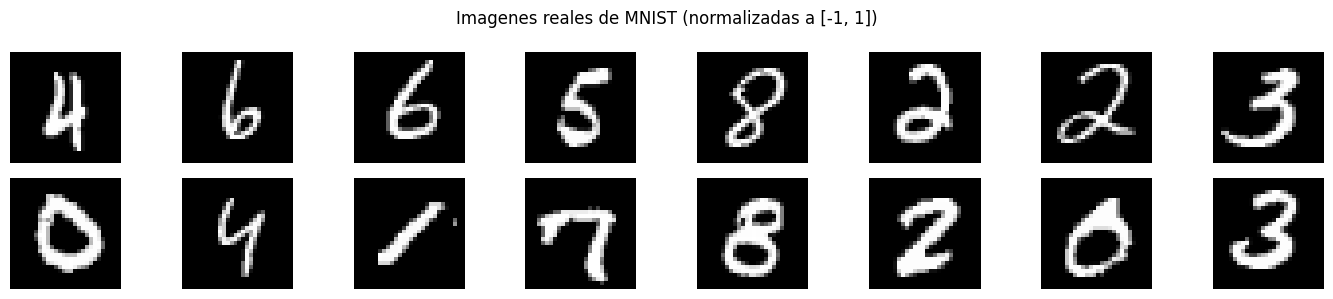

In [2]:
# Cargar MNIST y normalizar a [-1, 1] (coincide con la salida Tanh del generador)
(x_train, _), (_, _) = keras.datasets.mnist.load_data()
x_train = x_train.astype('float32')
x_train = (x_train - 127.5) / 127.5            # [0, 255] -> [-1, 1]
x_train = np.expand_dims(x_train, -1)          # (N, 28, 28, 1)

BATCH_SIZE = 128
Z_DIM      = 100

# Pipeline tf.data para entrenamiento eficiente
train_ds = (tf.data.Dataset.from_tensor_slices(x_train)
            .shuffle(60000)
            .batch(BATCH_SIZE, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))

print(f'Imagenes        : {x_train.shape}')
print(f'Rango de pixeles: [{x_train.min()}, {x_train.max()}]')
print(f'Batches         : {len(list(train_ds))}')


def show_grid(imgs, title='', nrow=8, figsize=(14, 3)):
    """Visualiza un grid de imagenes en [-1, 1]."""
    imgs = np.clip((imgs + 1) / 2, 0, 1)
    n    = len(imgs)
    cols = min(nrow, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_2d(axes)
    for i in range(rows * cols):
        ax = axes.flat[i]
        if i < n:
            ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    if title: plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


real_batch = next(iter(train_ds)).numpy()
show_grid(real_batch[:16], 'Imagenes reales de MNIST (normalizadas a [-1, 1])')

---

## 3. GAN Vanilla (MLP)

Arquitectura original de Goodfellow et al. (2014). Generador y discriminador son redes totalmente conectadas (MLP).

**Notas de diseño:**
- **LeakyReLU** en lugar de ReLU en D: evita gradientes en cero para valores negativos.
- **Dropout** en D: regularizacion para que D no sea demasiado poderoso.
- **Tanh** en la salida de G: produce valores en $[-1, 1]$.
- **Sigmoid** en la salida de D: probabilidad de ser real.

In [3]:
def build_vanilla_generator(z_dim=100):
    """Generador MLP: z -> imagen."""
    return keras.Sequential([
        keras.Input(shape=(z_dim,)),
        layers.Dense(256), layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(512), layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(1024), layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(784, activation='tanh'),
        layers.Reshape((28, 28, 1)),
    ], name='vanilla_generator')


def build_vanilla_discriminator():
    """Discriminador MLP: imagen -> probabilidad de ser real."""
    return keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Flatten(),
        layers.Dense(1024), layers.LeakyReLU(negative_slope=0.2), layers.Dropout(0.3),
        layers.Dense(512),  layers.LeakyReLU(negative_slope=0.2), layers.Dropout(0.3),
        layers.Dense(256),  layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(1, activation='sigmoid'),
    ], name='vanilla_discriminator')


G_vanilla = build_vanilla_generator(Z_DIM)
D_vanilla = build_vanilla_discriminator()

print(f'Parametros Generador     : {G_vanilla.count_params():,}')
print(f'Parametros Discriminador : {D_vanilla.count_params():,}')

Parametros Generador     : 1,486,352
Parametros Discriminador : 1,460,225


Entrenando GAN vanilla...
Epoca   1/30  Loss D: 0.5228  Loss G: 1.2896


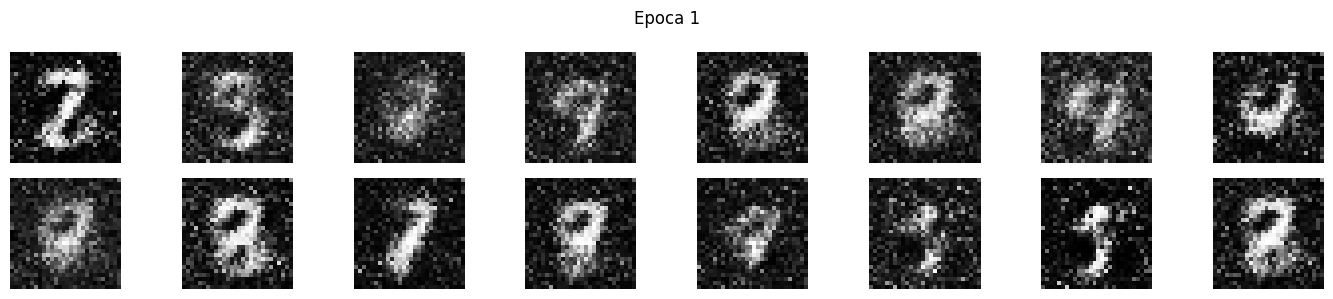

Epoca  10/30  Loss D: 0.5640  Loss G: 1.2256


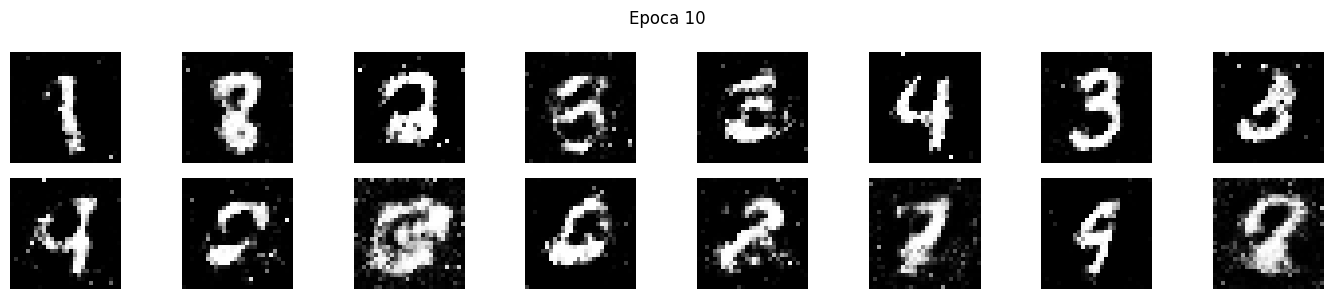

Epoca  20/30  Loss D: 0.6145  Loss G: 1.0546


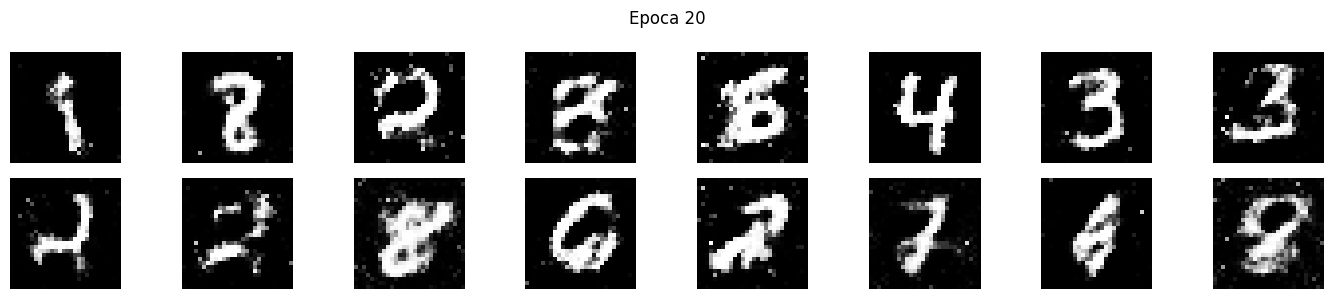

Epoca  30/30  Loss D: 0.6242  Loss G: 1.0220


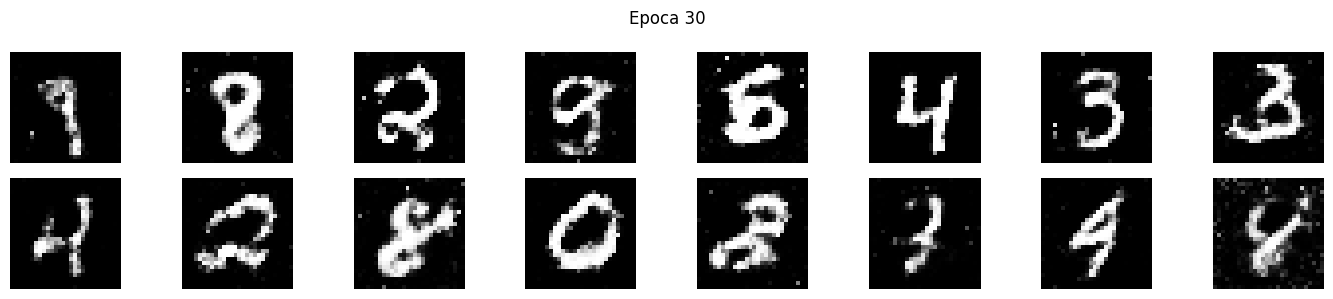

In [4]:
class GANTrainer:
    """
    Bucle de entrenamiento generico para GAN vanilla.

    Alterna en cada batch:
    1. Actualizar D: maximiza log D(x) + log(1 - D(G(z)))
    2. Actualizar G: maximiza log D(G(z))   [perdida no saturante]

    Usa label smoothing (0.9 en lugar de 1.0) para estabilizar D.
    Adam con beta_1=0.5 es la convencion en GANs (0.9 default tiende a oscilar).
    """
    def __init__(self, generator, discriminator, z_dim=100, lr=2e-4):
        self.G    = generator
        self.D    = discriminator
        self.z_dim = z_dim
        self.opt_G = keras.optimizers.Adam(lr, beta_1=0.5, beta_2=0.999)
        self.opt_D = keras.optimizers.Adam(lr, beta_1=0.5, beta_2=0.999)
        self.bce   = keras.losses.BinaryCrossentropy()

    @tf.function
    def train_step(self, real_imgs):
        bs = tf.shape(real_imgs)[0]

        # ---- Paso 1: Discriminador ----
        z         = tf.random.normal((bs, self.z_dim))
        fake_imgs = self.G(z, training=True)

        with tf.GradientTape() as tape:
            d_real     = self.D(real_imgs, training=True)
            d_fake     = self.D(fake_imgs, training=True)
            real_lbl   = tf.ones_like(d_real) * 0.9       # label smoothing
            fake_lbl   = tf.zeros_like(d_fake)
            loss_D     = (self.bce(real_lbl, d_real) + self.bce(fake_lbl, d_fake)) / 2

        grads = tape.gradient(loss_D, self.D.trainable_variables)
        self.opt_D.apply_gradients(zip(grads, self.D.trainable_variables))

        # ---- Paso 2: Generador ----
        z = tf.random.normal((bs, self.z_dim))
        with tf.GradientTape() as tape:
            fake_imgs = self.G(z, training=True)
            d_fake    = self.D(fake_imgs, training=True)
            # G quiere que D clasifique sus imagenes como reales
            loss_G    = self.bce(tf.ones_like(d_fake) * 0.9, d_fake)

        grads = tape.gradient(loss_G, self.G.trainable_variables)
        self.opt_G.apply_gradients(zip(grads, self.G.trainable_variables))

        return loss_D, loss_G

    def train(self, dataset, epochs=30, viz_every=10):
        history = defaultdict(list)
        fixed_z = tf.random.normal((16, self.z_dim))

        for epoch in range(1, epochs + 1):
            d_total = g_total = 0.0
            n_batches = 0

            for real_imgs in dataset:
                lD, lG = self.train_step(real_imgs)
                d_total += float(lD); g_total += float(lG); n_batches += 1

            history['D'].append(d_total / n_batches)
            history['G'].append(g_total / n_batches)

            if epoch % viz_every == 0 or epoch == 1:
                print(f'Epoca {epoch:3d}/{epochs}  Loss D: {history["D"][-1]:.4f}  Loss G: {history["G"][-1]:.4f}')
                samples = self.G(fixed_z, training=False).numpy()
                show_grid(samples, f'Epoca {epoch}', nrow=8, figsize=(14, 3))

        return history


print('Entrenando GAN vanilla...')
trainer_v = GANTrainer(G_vanilla, D_vanilla, z_dim=Z_DIM)
history_vanilla = trainer_v.train(train_ds, epochs=30)

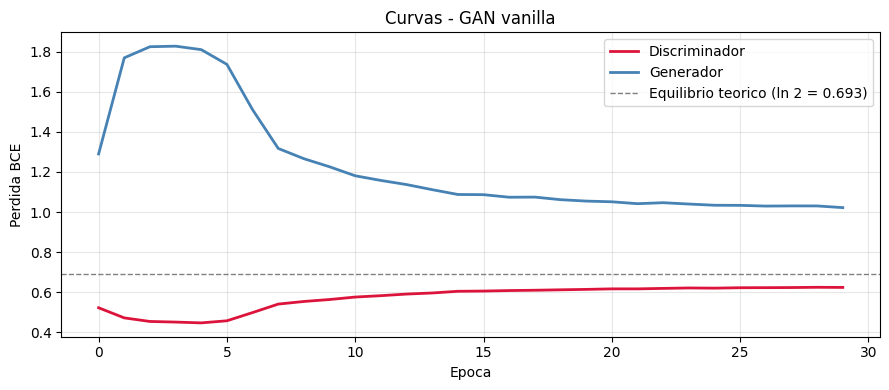

In [5]:
def plot_gan_losses(history, title='Curvas GAN'):
    """
    Curvas de perdida G y D.
    En equilibrio teorico la perdida de D converge a ln(2) ~ 0.693
    (50% de acierto: D no puede distinguir reales de falsos).
    """
    plt.figure(figsize=(9, 4))
    plt.plot(history['D'], label='Discriminador', color='crimson',   linewidth=2)
    plt.plot(history['G'], label='Generador',     color='steelblue', linewidth=2)
    plt.axhline(np.log(2), color='gray', linestyle='--', linewidth=1,
                label=f'Equilibrio teorico (ln 2 = {np.log(2):.3f})')
    plt.xlabel('Epoca'); plt.ylabel('Perdida BCE')
    plt.title(title); plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_gan_losses(history_vanilla, 'Curvas - GAN vanilla')

---

## 4. DCGAN — Deep Convolutional GAN

Radford et al. (2015) estabilizaron el entrenamiento con reglas arquitectonicas:

| Componente | Regla |
|------------|-------|
| Pooling | Eliminado. Se usa stride en Conv y Conv2DTranspose |
| BatchNormalization | En todas las capas excepto entrada de D y salida de G |
| Capas densas | Eliminadas |
| Activacion en G | ReLU en ocultas, Tanh en salida |
| Activacion en D | LeakyReLU(0.2) en todas |

In [6]:
def build_dc_generator(z_dim=100):
    """
    Generador DCGAN.
    Conv2DTranspose con stride=2 duplica la resolucion en cada capa.
    """
    return keras.Sequential([
        keras.Input(shape=(z_dim,)),
        layers.Dense(256 * 7 * 7),
        layers.ReLU(),
        layers.Reshape((7, 7, 256)),
        # (7, 7, 256) -> (14, 14, 128)
        layers.Conv2DTranspose(128, 4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        # (14, 14, 128) -> (28, 28, 64)
        layers.Conv2DTranspose(64,  4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        # (28, 28, 64) -> (28, 28, 1)  Tanh sin BN en la salida
        layers.Conv2D(1, 3, padding='same', activation='tanh', use_bias=False),
    ], name='dc_generator')


def build_dc_discriminator():
    """
    Discriminador DCGAN.
    Conv2D con stride=2 reduce la resolucion (en lugar de MaxPool).
    Sin BN en la primera capa (trabaja con pixeles directos).
    """
    return keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        # (28, 28, 1) -> (14, 14, 64)
        layers.Conv2D(64,  4, strides=2, padding='same', use_bias=False),
        layers.LeakyReLU(negative_slope=0.2),
        # (14, 14, 64) -> (7, 7, 128)
        layers.Conv2D(128, 4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid'),
    ], name='dc_discriminator')


G_dc = build_dc_generator(Z_DIM)
D_dc = build_dc_discriminator()

print(f'Parametros Generador     : {G_dc.count_params():,}')
print(f'Parametros Discriminador : {D_dc.count_params():,}')

# Verificar dimensiones
z_test = tf.random.normal((2, Z_DIM))
out_G  = G_dc(z_test)
out_D  = D_dc(out_G)
print(f'\nForma salida G : {out_G.shape}')
print(f'Forma salida D : {out_D.shape}')

Parametros Generador     : 1,923,648
Parametros Discriminador : 138,881

Forma salida G : (2, 28, 28, 1)
Forma salida D : (2, 1)


Entrenando DCGAN...
Epoca   1/30  Loss D: 0.5844  Loss G: 1.0471


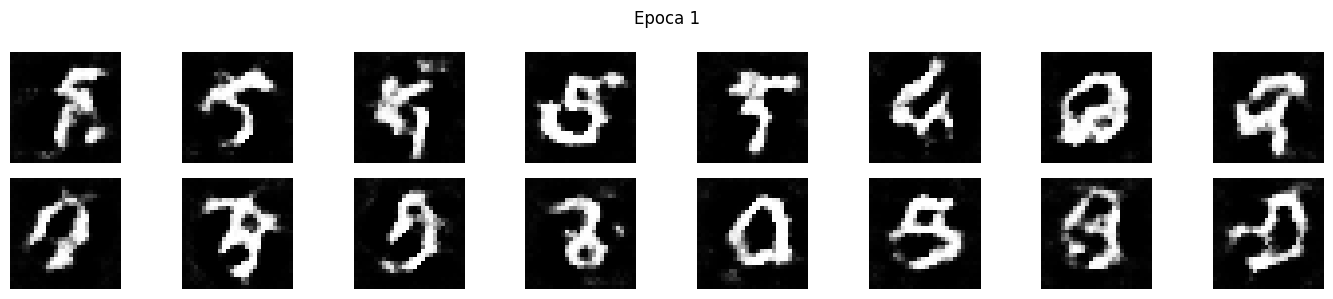

Epoca  10/30  Loss D: 0.6566  Loss G: 0.9019


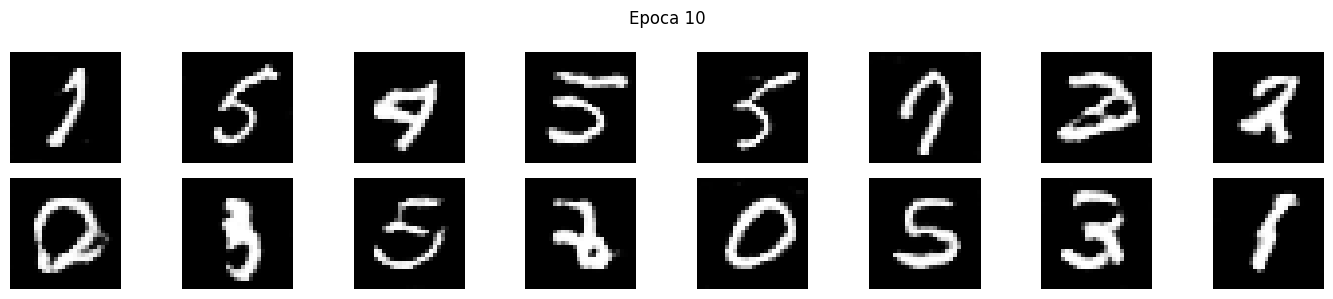

Epoca  20/30  Loss D: 0.6677  Loss G: 0.8694


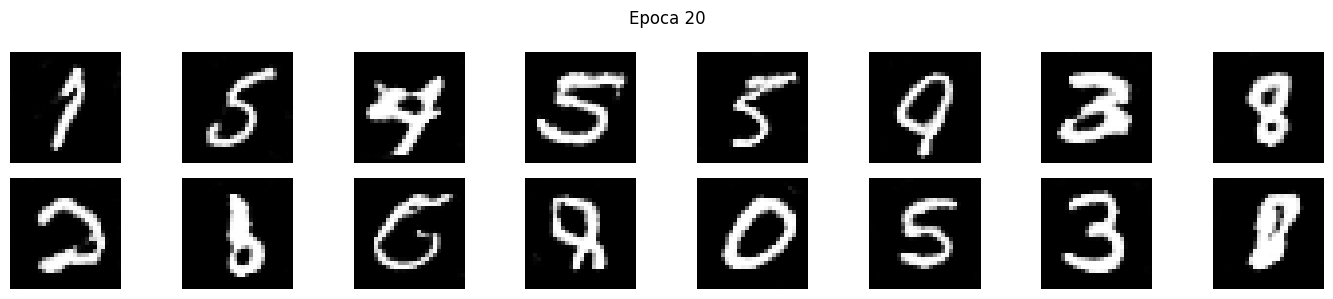

Epoca  30/30  Loss D: 0.6742  Loss G: 0.8558


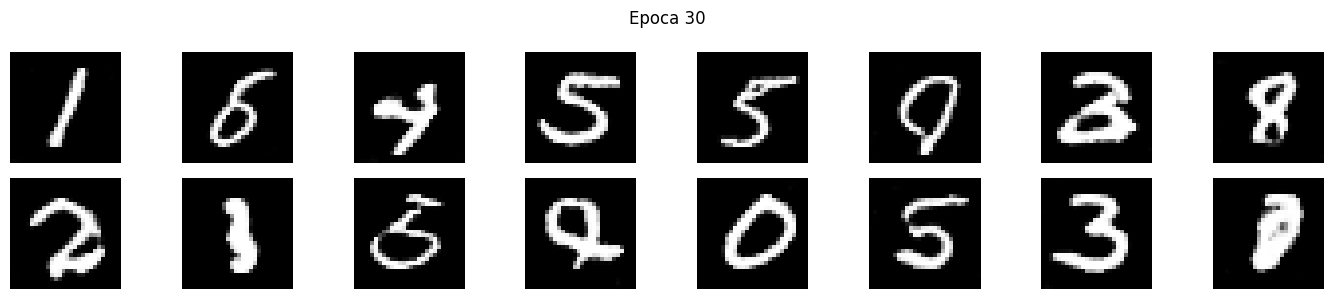

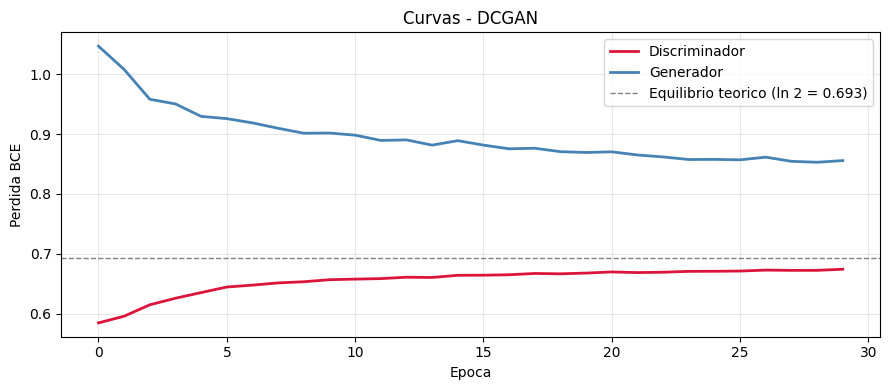

In [7]:
# El bucle de entrenamiento es el mismo que en la GAN vanilla
# La diferencia esta en la arquitectura, no en el algoritmo
print('Entrenando DCGAN...')
trainer_dc = GANTrainer(G_dc, D_dc, z_dim=Z_DIM)
history_dc = trainer_dc.train(train_ds, epochs=30)

plot_gan_losses(history_dc, 'Curvas - DCGAN')

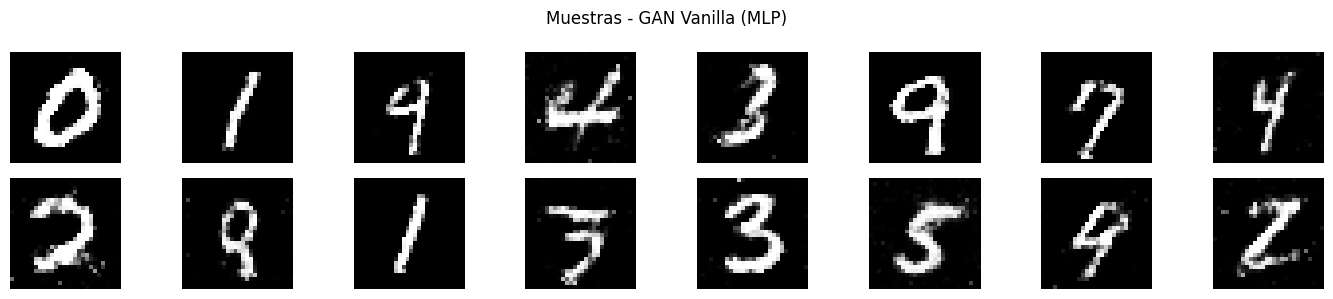

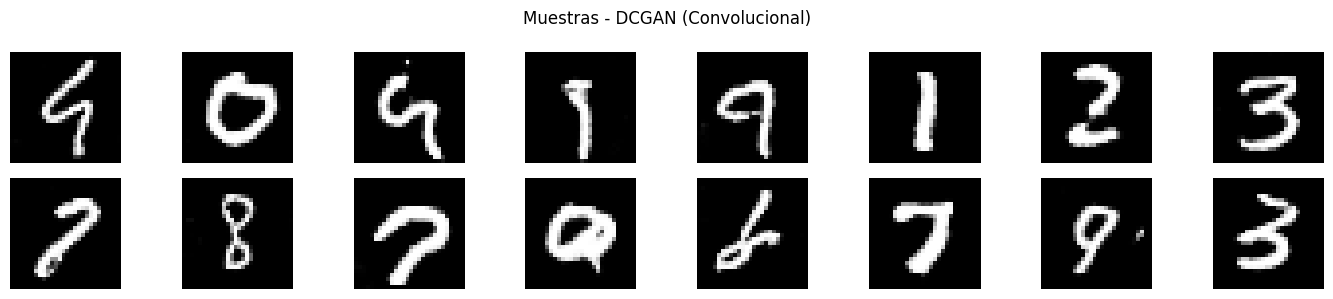

In [8]:
# Comparar muestras: GAN vanilla vs DCGAN
fixed_z = tf.random.normal((16, Z_DIM))
for G, name in [(G_vanilla, 'GAN Vanilla (MLP)'), (G_dc, 'DCGAN (Convolucional)')]:
    samples = G(fixed_z, training=False).numpy()
    show_grid(samples, f'Muestras - {name}', nrow=8, figsize=(14, 3))

---

## 5. GAN Condicional (cGAN)

La cGAN (Mirza & Osindero, 2014) condiciona G y D en una etiqueta de clase $y$:

$$\min_G \max_D \; \mathbb{E}_{x,y}[\log D(x, y)] + \mathbb{E}_{z,y}[\log(1 - D(G(z, y), y))]$$

Permite **controlar exactamente que digito se genera** mediante la etiqueta. La condicion se incorpora con un **embedding** que se concatena al ruido.

In [9]:
# Reusar MNIST con etiquetas
(_, y_train_full), (_, _) = keras.datasets.mnist.load_data()

# Pipeline con etiquetas
train_ds_labeled = (tf.data.Dataset.from_tensor_slices((x_train, y_train_full))
                    .shuffle(60000)
                    .batch(BATCH_SIZE, drop_remainder=True)
                    .prefetch(tf.data.AUTOTUNE))

N_CLASSES = 10
EMBED_DIM = 50

In [11]:
def build_conditional_generator(z_dim=100, n_classes=10, embed_dim=50):
    """
    Generador condicional con dos entradas: z (ruido) e y (clase).
    El embedding convierte la clase entera en un vector denso aprendible.
    """
    z_in = keras.Input(shape=(z_dim,))
    y_in = keras.Input(shape=(1,), dtype=tf.int32)
    y_emb = layers.Embedding(n_classes, embed_dim)(y_in)
    y_emb = layers.Flatten()(y_emb)
    x     = layers.Concatenate()([z_in, y_emb])

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(784, activation='tanh')(x)
    out = layers.Reshape((28, 28, 1))(x)

    return keras.Model([z_in, y_in], out, name='conditional_generator')


def build_conditional_discriminator(n_classes=10, embed_dim=50):
    x_in  = keras.Input(shape=(28, 28, 1))
    y_in  = keras.Input(shape=(1,), dtype=tf.int32)
    y_emb = layers.Embedding(n_classes, embed_dim)(y_in)
    y_emb = layers.Flatten()(y_emb)

    x = layers.Flatten()(x_in)
    x = layers.Concatenate()([x, y_emb])

    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model([x_in, y_in], out, name='conditional_discriminator')


G_cond = build_conditional_generator(Z_DIM, N_CLASSES, EMBED_DIM)
D_cond = build_conditional_discriminator(N_CLASSES, EMBED_DIM)
print(f'Parametros G_cond : {G_cond.count_params():,}')
print(f'Parametros D_cond : {D_cond.count_params():,}')

Parametros G_cond : 1,506,820
Parametros D_cond : 1,511,925


Entrenando cGAN...
Epoca   1/30  Loss D: 0.4474  Loss G: 2.5121


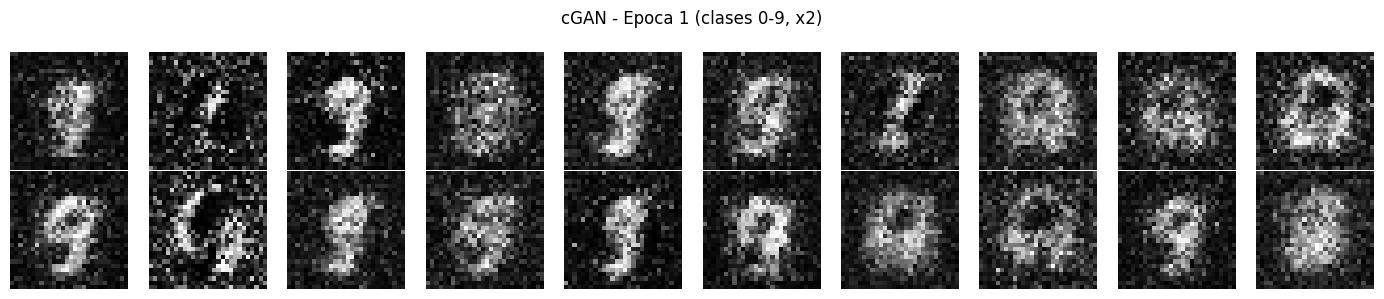

Epoca  10/30  Loss D: 0.6146  Loss G: 1.0415


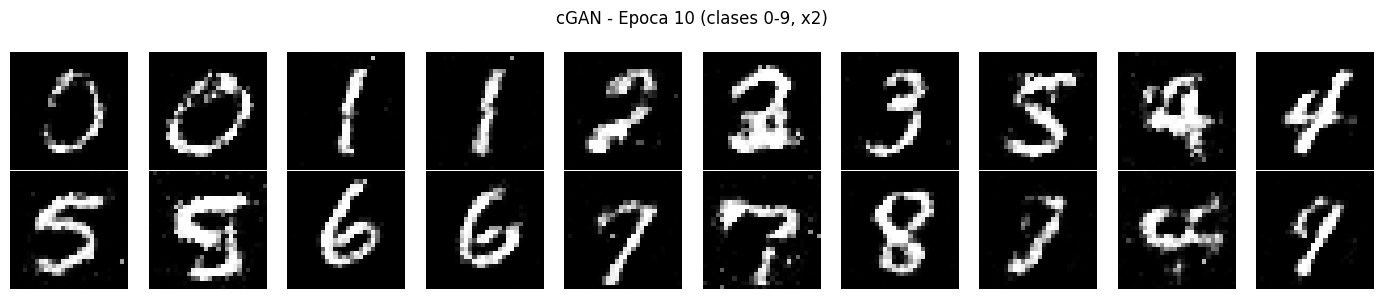

Epoca  20/30  Loss D: 0.6604  Loss G: 0.8888


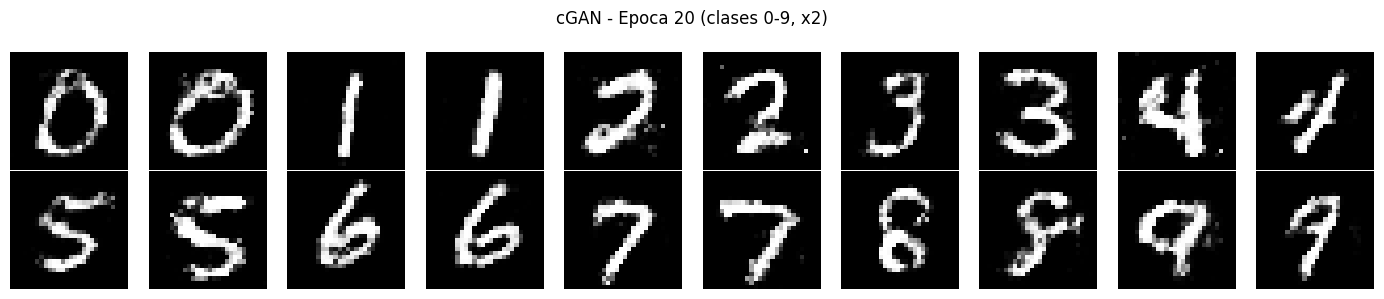

Epoca  30/30  Loss D: 0.6681  Loss G: 0.8590


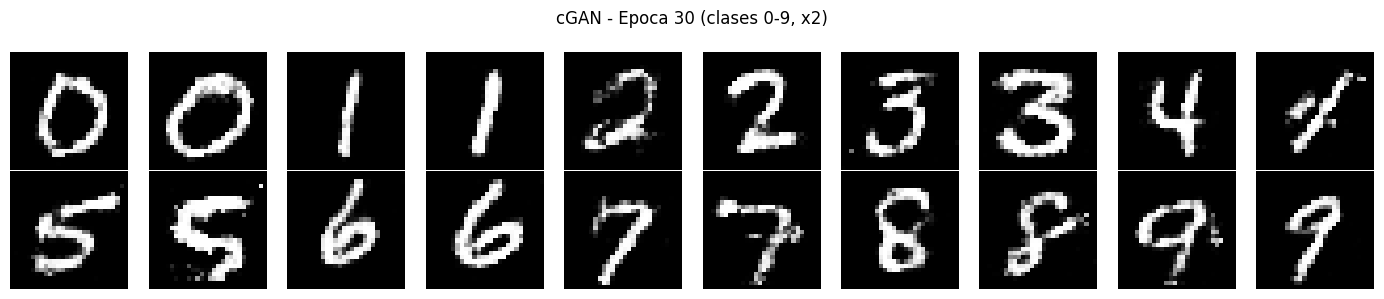

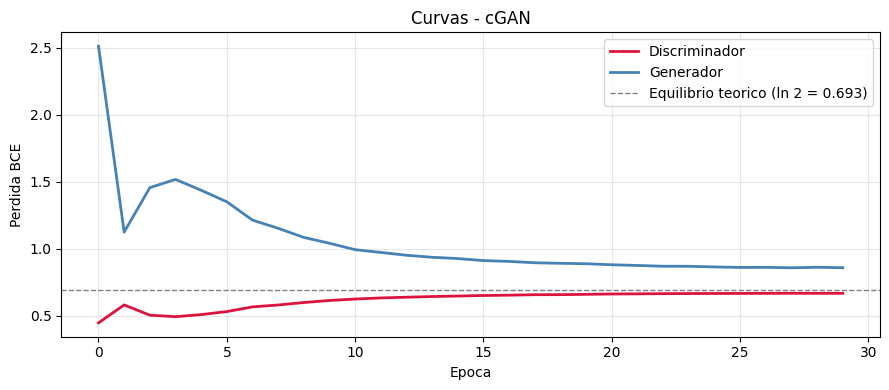

In [12]:
# Bucle de entrenamiento condicional
opt_G_c = keras.optimizers.Adam(2e-4, beta_1=0.5)
opt_D_c = keras.optimizers.Adam(2e-4, beta_1=0.5)
bce_c   = keras.losses.BinaryCrossentropy()

@tf.function
def train_step_cgan(real_imgs, real_labels):
    bs = tf.shape(real_imgs)[0]

    # ---- D ----
    z          = tf.random.normal((bs, Z_DIM))
    rand_lbls  = tf.random.uniform((bs, 1), 0, N_CLASSES, dtype=tf.int32)
    fake_imgs  = G_cond([z, rand_lbls], training=True)

    with tf.GradientTape() as tape:
        d_real = D_cond([real_imgs, tf.expand_dims(real_labels, -1)], training=True)
        d_fake = D_cond([fake_imgs, rand_lbls], training=True)
        loss_D = (bce_c(tf.ones_like(d_real)*0.9, d_real)
                  + bce_c(tf.zeros_like(d_fake), d_fake)) / 2
    grads = tape.gradient(loss_D, D_cond.trainable_variables)
    opt_D_c.apply_gradients(zip(grads, D_cond.trainable_variables))

    # ---- G ----
    z         = tf.random.normal((bs, Z_DIM))
    rand_lbls = tf.random.uniform((bs, 1), 0, N_CLASSES, dtype=tf.int32)
    with tf.GradientTape() as tape:
        fake_imgs = G_cond([z, rand_lbls], training=True)
        d_fake    = D_cond([fake_imgs, rand_lbls], training=True)
        loss_G    = bce_c(tf.ones_like(d_fake)*0.9, d_fake)
    grads = tape.gradient(loss_G, G_cond.trainable_variables)
    opt_G_c.apply_gradients(zip(grads, G_cond.trainable_variables))

    return loss_D, loss_G


history_cgan = defaultdict(list)
fixed_z_c    = tf.random.normal((20, Z_DIM))
fixed_y_c    = tf.constant([[i] for i in range(10) for _ in range(2)], dtype=tf.int32)

print('Entrenando cGAN...')
for epoch in range(1, 31):
    d_t = g_t = 0.0; n = 0
    for imgs, lbls in train_ds_labeled:
        lD, lG = train_step_cgan(imgs, lbls)
        d_t += float(lD); g_t += float(lG); n += 1
    history_cgan['D'].append(d_t/n); history_cgan['G'].append(g_t/n)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoca {epoch:3d}/30  Loss D: {d_t/n:.4f}  Loss G: {g_t/n:.4f}')
        samples = G_cond([fixed_z_c, fixed_y_c], training=False).numpy()
        show_grid(samples, f'cGAN - Epoca {epoch} (clases 0-9, x2)', nrow=10, figsize=(14, 3))

plot_gan_losses(history_cgan, 'Curvas - cGAN')

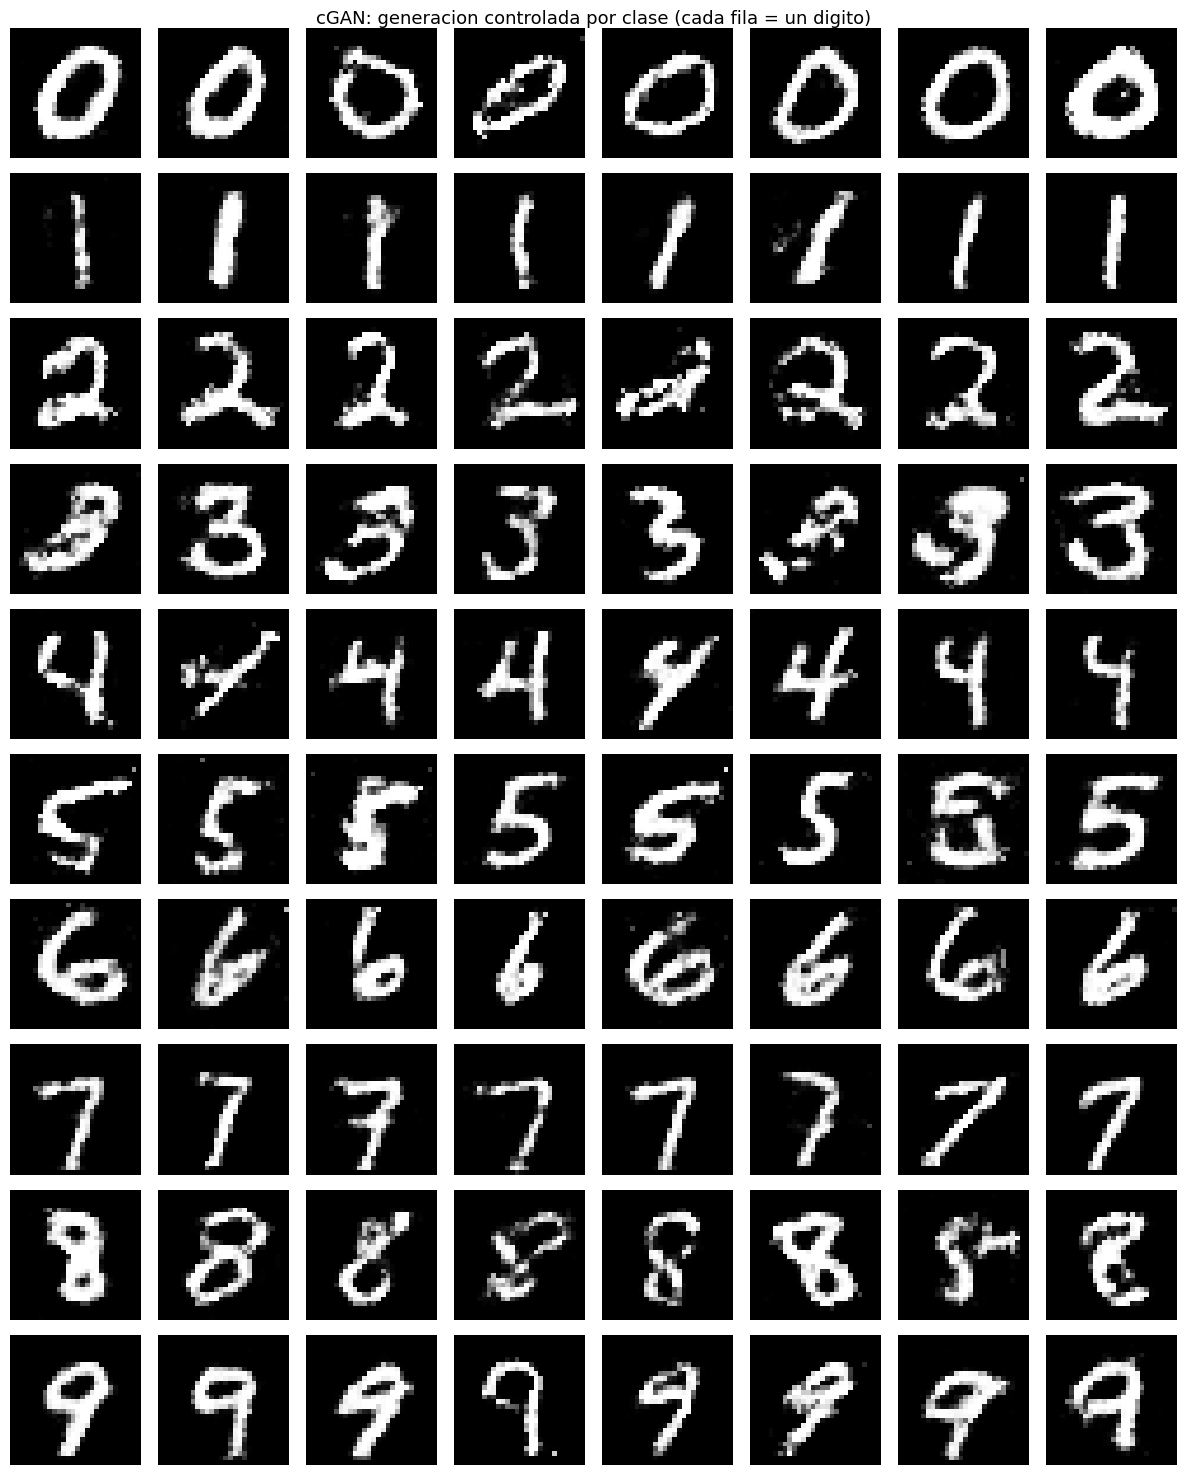

In [13]:
# Demostracion: control por clase con el mismo ruido
n_per_class = 8
fig, axes   = plt.subplots(N_CLASSES, n_per_class, figsize=(n_per_class*1.5, N_CLASSES*1.5))

for digit in range(N_CLASSES):
    z      = tf.random.normal((n_per_class, Z_DIM))
    labels = tf.constant([[digit]] * n_per_class, dtype=tf.int32)
    imgs   = G_cond([z, labels], training=False).numpy()
    imgs   = np.clip((imgs + 1) / 2, 0, 1)
    for i in range(n_per_class):
        axes[digit, i].imshow(imgs[i].squeeze(), cmap='gray')
        axes[digit, i].axis('off')
    axes[digit, 0].set_ylabel(f'{digit}', fontsize=11, rotation=0, labelpad=20, va='center')

plt.suptitle('cGAN: generacion controlada por clase (cada fila = un digito)', fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. WGAN con Gradiente Penalizado (WGAN-GP)

### Problema de la GAN vanilla
La perdida BCE mide la **divergencia Jensen-Shannon**. Cuando $p_{\text{data}}$ y $p_G$ tienen soporte disjunto (frecuente al inicio), JS es constante y los gradientes se anulan.

### Distancia de Wasserstein
$$W(p_{\text{data}}, p_G) = \sup_{\|f\|_L \leq 1} \mathbb{E}[f(x)] - \mathbb{E}[f(G(z))]$$

El discriminador se convierte en **critico** (sin sigmoid): produce un score real en $(-\infty, +\infty)$.

### Gradient Penalty
$$\mathcal{L}_{GP} = \lambda \; \mathbb{E}_{\hat{x}}[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2]$$

donde $\hat{x}$ se interpola entre real y falso. Impone Lipschitz de forma suave.

In [14]:
def build_wgan_generator(z_dim=100):
    """Generador WGAN-GP. Misma arquitectura que DCGAN."""
    return keras.Sequential([
        keras.Input(shape=(z_dim,)),
        layers.Dense(256 * 7 * 7), layers.ReLU(),
        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, 4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(), layers.ReLU(),
        layers.Conv2DTranspose(64,  4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(), layers.ReLU(),
        layers.Conv2D(1, 3, padding='same', activation='tanh', use_bias=False),
    ], name='wgan_generator')


def build_wgan_critic():
    """
    Critico para WGAN-GP.
    Diferencias clave:
    - Sin sigmoid (produce score real en (-inf, +inf)).
    - Sin BatchNorm (interfiere con el calculo del gradiente penalizado).
      Se usa LayerNormalization en su lugar.
    """
    return keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(64,  4, strides=2, padding='same', use_bias=False),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2D(128, 4, strides=2, padding='same', use_bias=False),
        layers.LayerNormalization(),                 # en lugar de BatchNorm
        layers.LeakyReLU(negative_slope=0.2),
        layers.Flatten(),
        layers.Dense(1),                             # SIN sigmoid
    ], name='wgan_critic')


G_wgan = build_wgan_generator(Z_DIM)
C_wgan = build_wgan_critic()
print(f'Parametros Generador : {G_wgan.count_params():,}')
print(f'Parametros Critico   : {C_wgan.count_params():,}')

Parametros Generador : 1,923,648
Parametros Critico   : 138,625


In [15]:
# WGAN-GP: hyperparametros
WGAN_LR     = 1e-4
N_CRITIC    = 5     # actualizaciones de C por cada actualizacion de G
LAMBDA_GP   = 10.0

opt_G_w = keras.optimizers.Adam(WGAN_LR, beta_1=0.0, beta_2=0.9)
opt_C_w = keras.optimizers.Adam(WGAN_LR, beta_1=0.0, beta_2=0.9)
# beta_1=0 recomendado en WGAN-GP

@tf.function
def gradient_penalty(real_imgs, fake_imgs):
    """
    Calcula la gradient penalty.

    1. Interpolar uniformemente entre real y falso: x_hat = a*real + (1-a)*fake
    2. Calcular gradiente de C(x_hat) respecto a x_hat
    3. Penalizar si la norma se aleja de 1
    """
    bs    = tf.shape(real_imgs)[0]
    alpha = tf.random.uniform((bs, 1, 1, 1), 0.0, 1.0)
    x_hat = alpha * real_imgs + (1 - alpha) * fake_imgs

    with tf.GradientTape() as tape:
        tape.watch(x_hat)
        score = C_wgan(x_hat, training=True)
    grads      = tape.gradient(score, x_hat)
    grads_norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
    return tf.reduce_mean((grads_norm - 1.0) ** 2)


@tf.function
def train_step_wgan(real_imgs):
    bs = tf.shape(real_imgs)[0]

    # ---- Actualizar Critico N_CRITIC veces ----
    for _ in range(N_CRITIC):
        z = tf.random.normal((bs, Z_DIM))
        with tf.GradientTape() as tape:
            fake_imgs   = G_wgan(z, training=True)
            score_real  = C_wgan(real_imgs, training=True)
            score_fake  = C_wgan(fake_imgs, training=True)
            gp          = gradient_penalty(real_imgs, fake_imgs)
            # Minimizar E[C(fake)] - E[C(real)] + lambda*GP
            loss_C      = (tf.reduce_mean(score_fake) - tf.reduce_mean(score_real)
                           + LAMBDA_GP * gp)
        grads = tape.gradient(loss_C, C_wgan.trainable_variables)
        opt_C_w.apply_gradients(zip(grads, C_wgan.trainable_variables))

    # ---- Actualizar Generador ----
    z = tf.random.normal((bs, Z_DIM))
    with tf.GradientTape() as tape:
        fake_imgs = G_wgan(z, training=True)
        loss_G    = -tf.reduce_mean(C_wgan(fake_imgs, training=True))
    grads = tape.gradient(loss_G, G_wgan.trainable_variables)
    opt_G_w.apply_gradients(zip(grads, G_wgan.trainable_variables))

    return loss_C, loss_G

Entrenando WGAN-GP...
Epoca   1/30  Loss C: -3.8365  Loss G: -22.8834  W-dist aprox: 3.8365


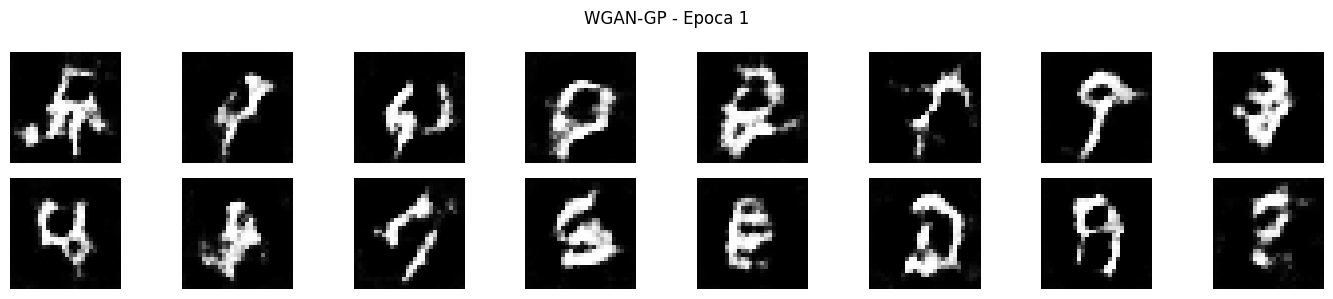

Epoca  10/30  Loss C: -0.1911  Loss G: -14.6452  W-dist aprox: 0.1911


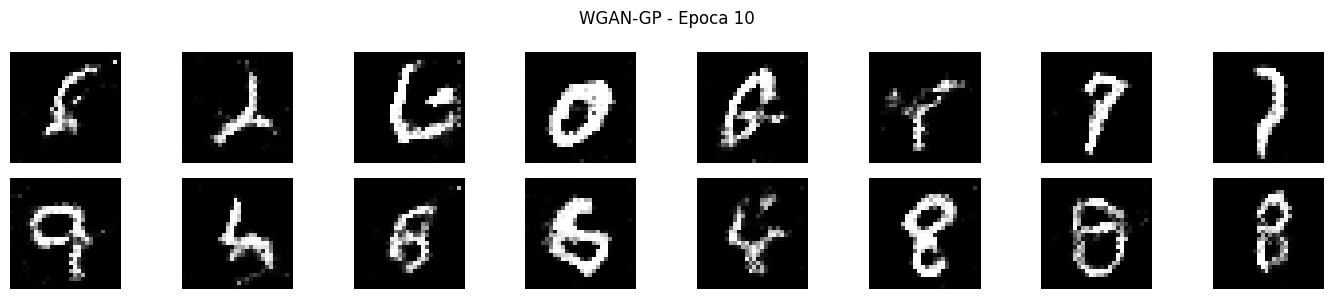

In [ ]:
history_wgan = defaultdict(list)
fixed_z_w    = tf.random.normal((16, Z_DIM))

print('Entrenando WGAN-GP...')
for epoch in range(1, 31):
    c_t = g_t = 0.0; n = 0
    for real_imgs in train_ds:
        lC, lG = train_step_wgan(real_imgs)
        c_t += float(lC); g_t += float(lG); n += 1
    history_wgan['C'].append(c_t/n); history_wgan['G'].append(g_t/n)
    if epoch % 10 == 0 or epoch == 1:
        wdist = -(c_t/n)
        print(f'Epoca {epoch:3d}/30  Loss C: {c_t/n:.4f}  Loss G: {g_t/n:.4f}  W-dist aprox: {wdist:.4f}')
        samples = G_wgan(fixed_z_w, training=False).numpy()
        show_grid(samples, f'WGAN-GP - Epoca {epoch}', nrow=8, figsize=(14, 3))

In [ ]:
# Curvas de WGAN-GP: la perdida del critico tiene interpretacion directa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_wgan['C'], color='crimson',    linewidth=2)
axes[0].set_title('Perdida del Critico\n(negativo aprox. de la distancia Wasserstein)')
axes[0].set_xlabel('Epoca'); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_wgan['G'], color='steelblue', linewidth=2)
axes[1].set_title('Perdida del Generador\n(-E[C(fake)])')
axes[1].set_xlabel('Epoca'); axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas - WGAN-GP', fontsize=13)
plt.tight_layout()
plt.show()

print('Nota: en WGAN-GP, la perdida del critico es significativa.')
print('Si disminuye (se hace mas negativa), la distancia Wasserstein decrece: G mejora.')

---

## 7. Problemas comunes y diagnostico

In [ ]:
def check_diversity(generator, z_dim, n_samples=128):
    """
    Detecta mode collapse midiendo la diversidad de las imagenes generadas.
    Mode collapse: G produce siempre el mismo output (std baja).
    """
    z    = tf.random.normal((n_samples, z_dim))
    imgs = generator(z, training=False).numpy()
    imgs = (imgs + 1) / 2
    return float(np.mean(np.std(imgs, axis=0)))


print('Diversidad de muestras (std promedio por pixel):')
print('Mas alta = mas diversidad. Cercana a 0 = mode collapse.\n')
for G, name in [(G_vanilla, 'GAN Vanilla'), (G_dc, 'DCGAN'), (G_wgan, 'WGAN-GP')]:
    div = check_diversity(G, Z_DIM)
    print(f'  {name:<15}: {div:.4f}')

In [ ]:
# Tabla de diagnostico
diagnostico = [
    ('Mode Collapse',       'G produce siempre el mismo output',
     'WGAN-GP, Minibatch Disc., aumentar z_dim'),
    ('Vanishing Gradients', 'D demasiado bueno, gradientes de G ~0',
     'WGAN-GP, Feature Matching, reducir D'),
    ('Inestabilidad',       'Perdidas oscilan, muestras degeneran',
     'Label smoothing, beta_1=0.5, BN, lr menor'),
    ('G no mejora',         'Las muestras no cambian a lo largo de las epocas',
     'Verificar gradientes, mas updates de G'),
    ('D colapsa a 0',       'D aprende muy rapido, loss_D -> 0',
     'Reducir D, Dropout, menos updates de D'),
]

print(f'{"Problema":<22} {"Sintoma":<48} {"Soluciones"}')
print('-' * 120)
for prob, sint, sol in diagnostico:
    print(f'{prob:<22} {sint:<48} {sol}')

---

## 8. Comparativa de variantes

In [ ]:
# Visualizar muestras finales de las 4 variantes
fixed_z = tf.random.normal((16, Z_DIM))
fixed_y7 = tf.constant([[7]]*16, dtype=tf.int32)

fig, axes = plt.subplots(4, 16, figsize=(24, 7))
nombres   = ['GAN Vanilla (MLP)', 'DCGAN', 'cGAN (digito 7)', 'WGAN-GP']
outputs   = [
    G_vanilla(fixed_z,           training=False).numpy(),
    G_dc(fixed_z,                training=False).numpy(),
    G_cond([fixed_z, fixed_y7],  training=False).numpy(),
    G_wgan(fixed_z,              training=False).numpy(),
]

for row, (imgs, nombre) in enumerate(zip(outputs, nombres)):
    imgs = np.clip((imgs + 1) / 2, 0, 1)
    for col in range(16):
        axes[row, col].imshow(imgs[col].squeeze(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(nombre, fontsize=9, rotation=0, labelpad=85, va='center')

plt.suptitle('Comparativa de muestras generadas - todas las variantes', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen
tabla = [
    ('GAN Vanilla', 'MLP',                 'BCE (minimax)',     'No', 'Baja',  'Prototipos, demos'),
    ('DCGAN',       'Conv/ConvTranspose',  'BCE no saturante',  'No', 'Media', 'Generacion de imagenes'),
    ('cGAN',        'MLP + Embedding',     'BCE condicional',   'Si', 'Media', 'Generacion controlada'),
    ('WGAN-GP',     'Conv + GP',           'Wasserstein + GP',  'No', 'Alta',  'Estabilidad critica'),
    ('Pix2Pix',     'U-Net + PatchGAN',    'BCE + L1',          'Si', 'Media', 'Imagen a imagen'),
    ('CycleGAN',    'ResNet + 2 D',        'BCE + ciclo',       'Si', 'Media', 'Sin pares'),
    ('StyleGAN2/3', 'Mapping + Synth.',    'No-sat + R1 reg.',  'Si', 'Alta',  'Alta resolucion'),
    ('BigGAN',      'Conv + Class BN',     'Hinge loss',        'Si', 'Alta',  'Datasets grandes'),
]

print('Resumen comparativo de variantes de GAN')
print('=' * 105)
print(f'{"Variante":<14} {"Arquitectura":<22} {"Perdida":<20} {"Control":<8} {"Estabilidad":<12} {"Uso"}')
print('-' * 105)
for row in tabla:
    print(f'{row[0]:<14} {row[1]:<22} {row[2]:<20} {row[3]:<8} {row[4]:<12} {row[5]}')

---

## Conclusiones

**GAN Vanilla**: la formulacion original. Funciona pero es fragil: susceptible a mode collapse, vanishing gradients y oscilaciones.

**DCGAN**: convolucion, BatchNorm e inicializacion cuidadosa estabilizan el entrenamiento.

**cGAN**: extension con embeddings de clase, permite controlar exactamente que tipo de imagen se genera.

**WGAN-GP**: distancia de Wasserstein + gradient penalty resuelve los problemas de estabilidad. La perdida del critico tiene interpretacion directa: si baja, G mejora. Es la variante mas robusta de las implementadas.

Eleccion segun el caso de uso:
- **Prototipado rapido**: DCGAN.
- **Control de clase**: cGAN.
- **Estabilidad critica o datos complejos**: WGAN-GP.
- **Alta resolucion**: StyleGAN2/3 o modelos de difusion.

---

## Referencias

- Goodfellow, I., et al. (2014). Generative adversarial nets. *NeurIPS 2014*.
- Radford, A., Metz, L., & Chintala, S. (2015). Unsupervised representation learning with DCGANs. *arXiv:1511.06434*.
- Mirza, M., & Osindero, S. (2014). Conditional GANs. *arXiv:1411.1784*.
- Arjovsky, M., Chintala, S., & Bottou, L. (2017). Wasserstein GAN. *arXiv:1701.07875*.
- Gulrajani, I., et al. (2017). Improved training of Wasserstein GANs. *NeurIPS 2017*.